In [54]:
from dotenv import load_dotenv

load_dotenv()

True

### Base Model

In [55]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1"
)

In [56]:
# test
llm.invoke("Hello, how are you?")

AIMessage(content='Hello! I’m just a bunch of code, but I appreciate you asking. How can I help you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 13, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlB1dmU52XNofX8SbW09XP3AvW3gq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--2b11485a-bc60-42ce-99dd-04268cabc0a8-0', usage_metadata={'input_tokens': 13, 'output_tokens': 24, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Embedding Model

In [57]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

In [58]:
# test
len(embeddings.embed_query("Hello, how are you?"))

3072

### RAG

In [59]:
url = "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [60]:
from langchain_community.document_loaders import WebBaseLoader

web_loader = WebBaseLoader(url)
data = web_loader.load()
data[0].metadata  # Display the first 1000 characters of the content

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [61]:
# Multiple URLs can be loaded similarly

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/"
]

docs = [WebBaseLoader(url).load() for url in urls]
[data[0].metadata for data in docs]

[{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
  'title': "LLM Powered Autonomous Agents | Lil'Log",
  'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemo

In [62]:
docs_list = [doc for data in docs for doc in data]

#### Chunking

In [63]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100,
    chunk_overlap=25
)

doc_splitter = text_splitter.split_documents(docs_list)

In [64]:
doc_splitter[0]

Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resul

#### Vector Store

In [65]:
from langchain_community.vectorstores import Chroma

In [66]:
vectorstore = Chroma.from_documents(
    documents=doc_splitter,
    embedding=embeddings,
    collection_name="rag-chroma",
    persist_directory="/Users/amarmandal/Documents/coding/GenAI_Course/data/rag-chroma"
)

In [67]:
retriever = vectorstore.as_retriever()

In [68]:
retriever.invoke("What is the difference between RAG and traditional LLMs?")

[Document(metadata={'language': 'en', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the qua

#### Retriever Tool

In [125]:
from langchain.tools.retriever import create_retriever_tool

In [126]:
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retriever_blog_post",
    description="Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs."
)

In [127]:
tools = [retriever_tool]

#### Tool Node

In [128]:
from langgraph.prebuilt import ToolNode

In [129]:
retriever_node = ToolNode(tools)

### State

In [130]:
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [143]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

### Graph

In [144]:
from langchain_core.prompts import PromptTemplate

In [169]:
llm_with_tool = llm.bind_tools(tools)

def LLM_Decision_Maker(state:AgentState):
    print("----CALL LLM_DECISION_MAKE----")
    message=state["messages"]
    last_message=message[-1]
    question=last_message.content
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

In [170]:
llm_with_tool.invoke("Tell me about LLM Powered Automation Agents.")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_QFD0NeZ9vWkpNUweqao2wm9g', 'function': {'arguments': '{"query":"LLM Powered Automation Agents"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 85, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlBGIycBKykYWd5NlpZZ9hb65TQlF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c08bd576-e33f-44f1-a8b7-05caa17b93cd-0', tool_calls=[{'name': 'retriever_blog_post', 'args': {'query': 'LLM Powered Automation Agents'}, 'id': 'call_QFD0NeZ9vWkpNUweqao2wm9g', 'type': 'tool_call'}], usage_metadata={'input_tokens': 85, 'output_t

In [171]:
from pydantic import BaseModel, Field

class Grade(BaseModel):
    binary_score: str = Field(
        description="Relevance score for the retrieved content, either 'yes' or 'no'."
    )

In [184]:
def grade_document(state: AgentState):
    print("----CALL GRADE_DOCUMENT----")
    llm_struct_output = llm.with_structured_output(Grade)
    
    prompt = PromptTemplate(
        template="""You are a grader decider assistant, you will be given a question and a retrieved document. \
            You need to determine if the retrieved document is relevant to the question. \
            If it is relevant, return 'yes', otherwise return 'no'. \
            Here is the question: {question} \
            Here is the retrieved document: {retrieved_document}""",
        input_variables=["question", "retrieved_document"]
    )
    chain = prompt | llm_struct_output
    
    question = state["messages"][0].content
    last_message = state["messages"][-1]
    docs = last_message.content
    
    scored_result = chain.invoke({
        "question": question,
        "retrieved_document": docs
    })
    
    if scored_result.binary_score == "yes":
        print("----Relevant Document Found----")
        return "generator"
    else:
        print("----No Relevant Document Found----")
        return "retriever"


In [185]:
from langchain import hub
hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [186]:
def generate(state: AgentState):
    print("----CALL GENERATOR----")
    message = state["messages"]
    question = message[0].content
    last_message = message[-1]
    docs = last_message.content
    
    prompt = hub.pull("rlm/rag-prompt")
    
    rag_chain = prompt | llm
    response = rag_chain.invoke({
        "question": question,
        "context": docs
    })
    
    return {"messages": [response]}

In [187]:
def rewrite(state: AgentState):
    print("----TRANSFORMER REWRITE----")
    message = state["message"]
    question = message[0].content
    
    input_prompt = [
        HumanMessage(
            content=f"Look at the input and try to reason about the underlying semantic intent or meaning. \
                Then, rewrite the input to be more clear and concise. \
                Here is the input: {question}"
        )
    ]
    
    response = llm.invoke(input_prompt)
    return {"message": [response]}

In [188]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

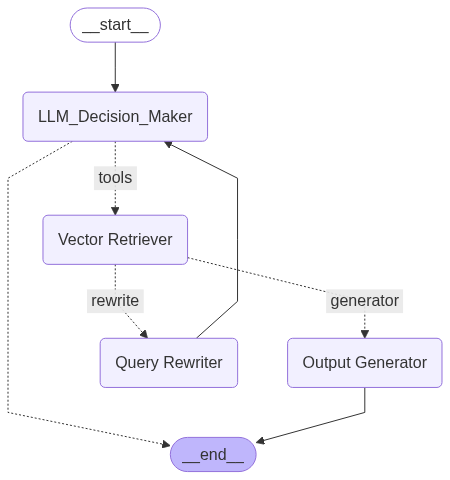

In [189]:
workflow = StateGraph(AgentState)

workflow.add_node("LLM_Decision_Maker", LLM_Decision_Maker)
workflow.add_node("Vector Retriever", retriever_node)
workflow.add_node("Output Generator", generate)
workflow.add_node("Query Rewriter", rewrite)

workflow.add_edge(START, "LLM_Decision_Maker")
workflow.add_conditional_edges(
    "LLM_Decision_Maker",
    tools_condition,
    {
        "tools": "Vector Retriever",
        END: END
    }
)

workflow.add_conditional_edges(
    "Vector Retriever",
    grade_document,
    {
        "generator": "Output Generator",
        "rewrite": "Query Rewriter"
    }
)

workflow.add_edge("Output Generator", END)
workflow.add_edge("Query Rewriter", "LLM_Decision_Maker")

app = workflow.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [190]:
app.invoke({
    "messages": [
        HumanMessage(
            content="Tell me about LLM Powered Automation Agents. And how do they differ from traditional LLMs?"
        )    ]
})

----CALL LLM_DECISION_MAKE----
----CALL GRADE_DOCUMENT----
----Relevant Document Found----
----CALL GENERATOR----


{'messages': [HumanMessage(content='Tell me about LLM Powered Automation Agents. And how do they differ from traditional LLMs?', additional_kwargs={}, response_metadata={}, id='a196225a-c46f-4bb7-9cfc-f53ed02a9c70'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_lAeTN7ATde4mtWzADXCEAlUs', 'function': {'arguments': '{"query":"LLM Powered Automation Agents"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 96, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlBKQC83BgWqfAlLLj4rG0vIfPkjq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e591a807-5c99-4cef-ba3a-8